# Human demo charts (rapid prototype)

Prototype RL-page human charts **without Flask**. Data via `data_upset`.

Hand layout (2×2):
```
[0 top-L] [1 top-R]   ← public
[2 bot-L] [3 bot-R]   ← private (deal)
```

**X-axis = human turn (T1–T4)** — the human's 1st…4th recorded action on that hole.
When the opponent goes first, the game counter labels those R2–R5; we still plot them as T1–T4 so first/second seat lines up.

Re-run **Reload + fetch** after editing `data_upset.py`.


In [14]:
from __future__ import annotations

import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
BACKEND = None
for p in [HERE, HERE / "backend", HERE.parent, HERE.parent.parent]:
    if (p / "data_upset.py").exists():
        BACKEND = p.resolve()
        break
if BACKEND is None:
    raise FileNotFoundError("Could not find data_upset.py")

if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
os.chdir(BACKEND)
print("cwd:", Path.cwd())

cwd: C:\Users\kbwil\Documents\Data_Projects\golf\Golf_solver\backend


In [ ]:
import data_upset

data_upset = importlib.reload(data_upset)
summary = data_upset.fetch_human_demo_score_summary()
abr = summary.get("action_by_round") or {}
abb = summary.get("action_by_board") or {}
print("holes", summary.get("holes"), "steps", summary.get("steps"))
print(
    "axis", abb.get("axis"), "turns", abb.get("rounds"),
    "human_first", abb.get("holes_human_first"),
    "human_second", abb.get("holes_human_second"),
)
print("action turns", abr.get("rounds"), "second", abr.get("holes_human_second"))


def _turn_label(n) -> str:
    return f"T{n}"


def _board_figure(n_t: int, title: str, legend_handles=None, legend_ncol=3):
    """Title on top, boards in middle, legend below — no overlap."""
    fig_h = 4.6 if legend_handles else 4.0
    fig = plt.figure(figsize=(max(7.5, 1.9 * n_t), fig_h))
    outer = fig.add_gridspec(
        2, n_t,
        height_ratios=[1.0, 0.12],
        hspace=0.2,
        wspace=0.4,
        left=0.06, right=0.99,
        top=0.88 if legend_handles else 0.90,
        bottom=0.20 if legend_handles else 0.10,
    )
    fig.suptitle(title, fontsize=11, y=0.98)
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=legend_ncol,
            fontsize=8,
            frameon=False,
            bbox_to_anchor=(0.5, 0.02),
        )
    return fig, outer


def _style_slot_ax(ax, label: str):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor("none")
    ax.set_xlabel(label, fontsize=7, labelpad=3)


## Score histogram

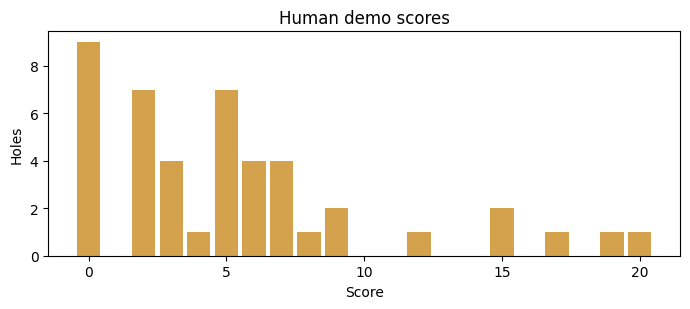

In [16]:
hist = summary.get("score_histogram") or {}
if hist.get("available"):
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.bar(hist["bin_centers"], hist["counts"], color="#d4a24c", width=0.85)
    ax.set_xlabel("Score"); ax.set_ylabel("Holes"); ax.set_title("Human demo scores")
    plt.tight_layout(); plt.show()
else:
    print("no hist")

## Action mix by human turn

X-axis is the human's Nth action on the hole (**T1–T4**), aligned whether they went first or second.


In [ ]:
def plot_action_by_round(abr: dict):
    if not abr.get("available"):
        print("No action_by_round"); return
    turns, share = abr["rounds"], abr["share"]
    types = abr.get("types") or ["take_discard", "draw_keep", "draw_flip"]
    colors = {"take_discard": "#5a9e6e", "draw_keep": "#d4a24c", "draw_flip": "#7896be"}
    x = np.arange(len(turns)); bottom = np.zeros(len(turns))
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    for t in types:
        vals = np.array(share.get(t) or [0] * len(turns), dtype=float)
        ax.bar(x, vals, bottom=bottom, label=t.replace("_", " "), color=colors[t], width=0.72)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([_turn_label(t) for t in turns])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of actions")
    ax.set_xlabel("Human turn on hole (T1 = first action, whether or not they dealt first)")
    n1 = abr.get("holes_human_first") or 0
    n2 = abr.get("holes_human_second") or 0
    ax.set_title(f"Action mix by human turn   ({n1} holes human-first, {n2} human-second)", fontsize=11, pad=12)
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.subplots_adjust(right=0.78, bottom=0.18, top=0.88)
    plt.show()

plot_action_by_round(abr)


## Action mix by card slot (2×2)

Columns = **human turns T1–T4**. Legend sits under the figure.


In [ ]:
def plot_hand_grid_by_round(abb: dict):
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    turns = abb["rounds"]
    types = abb["types"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    colors = {"take_discard": "#3f7a52", "draw_keep": "#b8862f", "draw_flip": "#5a7599"}
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    n_t = len(turns)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[t], label=t.replace("_", " "))
        for t in types
    ]
    n1 = abb.get("holes_human_first") or 0
    n2 = abb.get("holes_human_second") or 0
    title = f"Action mix by card slot — human turns T1–T{turns[-1] if turns else 4}  ({n1} 1st / {n2} 2nd)"
    fig, outer = _board_figure(n_t, title, handles, legend_ncol=3)

    for ti, tn in enumerate(turns):
        inner = outer[0, ti].subgridspec(2, 2, wspace=0.4, hspace=0.65)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                tot = float(abb["totals"][ti][pos] or 0)
                bottom = 0.0
                if tot > 0:
                    for t in types:
                        v = float(abb["counts"][t][ti][pos]) / tot
                        if v <= 0:
                            continue
                        ax.bar([0], [v], bottom=bottom, color=colors[t], width=1.0, linewidth=0)
                        bottom += v
                ax.set_xlim(-0.5, 0.5)
                ax.set_ylim(0, 1)
                role = "pub" if pos < 2 else "priv"
                _style_slot_ax(ax, f"{role} {labels[pos]}")
                if tot:
                    ax.text(0.97, 0.95, str(int(tot)), transform=ax.transAxes,
                            ha="right", va="top", fontsize=6, color="#555")
        ax_lab = fig.add_subplot(outer[1, ti])
        ax_lab.axis("off")
        ax_lab.text(0.5, 0.55, _turn_label(tn), transform=ax_lab.transAxes,
                    ha="center", va="center", fontsize=10, fontweight="bold")
    plt.show()


plot_hand_grid_by_round(abb)


## Which card flipped (by human turn)

Draw-and-flip only. Columns = T1–T4. Darker = larger share of that turn’s flips.


In [ ]:
def plot_flips_by_round(abb: dict):
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    turns = abb["rounds"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    flip = abb["counts"]["draw_flip"]
    n_t = len(turns)
    n_flip = int(sum(sum(row) for row in flip))
    n1 = abb.get("holes_human_first") or 0
    n2 = abb.get("holes_human_second") or 0
    title = f"Which card flipped — human turns ({n_flip} flips; {n1} 1st / {n2} 2nd seat)"
    fig, outer = _board_figure(n_t, title, legend_handles=None)

    for ti, tn in enumerate(turns):
        row_counts = flip[ti]
        turn_tot = float(sum(row_counts) or 0)
        inner = outer[0, ti].subgridspec(2, 2, wspace=0.4, hspace=0.65)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                v = float(row_counts[pos])
                share = (v / turn_tot) if turn_tot else 0.0
                alpha = 0.12 + 0.88 * share if v else 0.06
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_facecolor((90 / 255, 117 / 255, 153 / 255, alpha))
                role = "pub" if pos < 2 else "priv"
                _style_slot_ax(ax, f"{role} {labels[pos]}")
                if v:
                    ax.text(0.5, 0.55, f"{int(v)}", transform=ax.transAxes,
                            ha="center", va="center", fontsize=8, color="#111", fontweight="bold")
                    ax.text(0.5, 0.28, f"{share:.0%}", transform=ax.transAxes,
                            ha="center", va="center", fontsize=6.5, color="#222")
                else:
                    ax.text(0.5, 0.5, "—", transform=ax.transAxes,
                            ha="center", va="center", fontsize=8, color="#999")
        ax_lab = fig.add_subplot(outer[1, ti])
        ax_lab.axis("off")
        ax_lab.text(0.5, 0.55, _turn_label(tn), transform=ax_lab.transAxes,
                    ha="center", va="center", fontsize=10, fontweight="bold")
    plt.show()


plot_flips_by_round(abb)


## Strategy: replace vs reveal

Same 2×2 × human-turn layout. Legend under the figure (not on the title).


In [ ]:
def plot_replace_vs_reveal(abb: dict):
    if not abb.get("available") or abb.get("mode") != "hand_2x2":
        print("Need action_by_board mode=hand_2x2:", abb.get("mode"), abb.get("message"))
        return
    turns = abb["rounds"]
    labels = abb.get("position_labels") or ["top-L", "top-R", "bot-L", "bot-R"]
    grid_pos = abb.get("grid") or [[0, 1], [2, 3]]
    n_t = len(turns)
    colors = {"replace": "#4a8f5c", "reveal": "#5a7599"}
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["replace"], label="replace (take+keep)"),
        plt.Rectangle((0, 0), 1, 1, color=colors["reveal"], label="reveal (flip)"),
    ]
    n1 = abb.get("holes_human_first") or 0
    n2 = abb.get("holes_human_second") or 0
    title = f"Strategy: replace vs reveal — human turns  ({n1} 1st / {n2} 2nd seat)"
    fig, outer = _board_figure(n_t, title, handles, legend_ncol=2)

    for ti, tn in enumerate(turns):
        inner = outer[0, ti].subgridspec(2, 2, wspace=0.4, hspace=0.65)
        for row in range(2):
            for col in range(2):
                pos = grid_pos[row][col]
                ax = fig.add_subplot(inner[row, col])
                take = float(abb["counts"]["take_discard"][ti][pos])
                keep = float(abb["counts"]["draw_keep"][ti][pos])
                flip = float(abb["counts"]["draw_flip"][ti][pos])
                replace = take + keep
                tot = replace + flip
                if tot > 0:
                    ax.bar([0], [replace / tot], bottom=0.0, color=colors["replace"], width=1.0, linewidth=0)
                    ax.bar([0], [flip / tot], bottom=replace / tot, color=colors["reveal"], width=1.0, linewidth=0)
                ax.set_xlim(-0.5, 0.5)
                ax.set_ylim(0, 1)
                role = "pub" if pos < 2 else "priv"
                _style_slot_ax(ax, f"{role} {labels[pos]}")
                if tot:
                    ax.text(0.5, 0.58, f"n={int(tot)}", transform=ax.transAxes,
                            ha="center", va="center", fontsize=6.5, color="#111",
                            bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                                      alpha=0.7, edgecolor="none"))
                    ax.text(0.5, 0.22, f"{flip / tot:.0%} flip", transform=ax.transAxes,
                            ha="center", va="center", fontsize=6, color="#222",
                            bbox=dict(boxstyle="round,pad=0.1", facecolor="white",
                                      alpha=0.6, edgecolor="none"))
                else:
                    ax.text(0.5, 0.5, "—", transform=ax.transAxes,
                            ha="center", va="center", fontsize=8, color="#999")
        ax_lab = fig.add_subplot(outer[1, ti])
        ax_lab.axis("off")
        ax_lab.text(0.5, 0.55, _turn_label(tn), transform=ax_lab.transAxes,
                    ha="center", va="center", fontsize=10, fontweight="bold")
    plt.show()


plot_replace_vs_reveal(abb)


## Raw peek

In [21]:
rows = (
    data_upset.supabase.table("human_demos")
    .select("round_num,action,action_key,created_at")
    .neq("game_id", "test_probe")
    .limit(8)
    .execute()
).data or []
for r in rows:
    pos = data_upset._action_target_pos(r.get("action"), r.get("action_key"))
    at = data_upset._classify_human_action(r.get("action"), r.get("action_key"))
    print(r.get("round_num"), at, "pos", pos, r.get("action_key"))

1 take_discard pos 0 ak
1 take_discard pos 0 take_discard_0
2 draw_keep pos 0 draw_deck_0
1 take_discard pos 2 take_discard_2
2 draw_flip pos 3 draw_deck_flip_3
3 take_discard pos 1 take_discard_1
4 draw_flip pos 0 draw_deck_flip_0
1 draw_flip pos 3 draw_deck_flip_3
